# Tema

Sa se creeze si antreneze o retea de tip convolutional pentru setul de date [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). Intrarea este RGB, de forma 32 x 32 x 3. Reteaua va avea urmatoarea arhitectura:

| Strat       | Numar filtre/neuroni | Dimensiune kernel |  Stride | Dim. harta de trasaturi |
| ------------|----------------------|-------------------|---------|-------------------------|
| Conv 1      |          32          |        3x3        |    1    |      30 x 30 x 32       |
| Conv 2      |          64          |        3x3        |    1    |      28 x 28 x 64       |
| Conv 3      |          128         |        3x3        |    1    |      26 x 26 x 128      |
| Pool 4      |          128         |         2         |    2    |      13 x 13 x 128      |
| Conv 5      |          256         |        3x3        |    1    |      11 x 11 x 256      |
| Conv 6      |          512         |        3x3        |    1    |       9 x  9 x 512      |
| Pool 7      |          512         |        3x3        |    3    |       3 x  3 x 512      |
| Conv 8      |          1024        |        3x3        |    1    |       1 x  1 x 1024     |
| Linear 9    |           -          |         -         |    -    |           100           |
| Linear 10   |           -          |         -         |    -    |            10           |

Puteti utiliza cod din fisierul notebook-ul 01_PyTorch_CNN.ipynb. Efectuati minim 20 de epoci de instruire. Reprezentati grafic folosind Tensorboard evolutia functiei de cost si a acuratetei, masurate pe setul de validare, precum si evolutia functiei de cost pe perioada antrenarii.

## Import de pachete și configurarea mediului

În această secțiune sunt instalate și importate bibliotecile necesare implementării rețelei neuronale convoluționale și antrenării pe setul de date CIFAR-10. Dacă este disponibilă o placă grafică compatibilă CUDA, antrenarea se va efectua pe GPU.

In [1]:
# Instalarea pachetelor necesare (se rulează doar la configurarea inițială a mediului)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install matplotlib
!pip install torch-summary
!pip install tensorboard

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importul bibliotecilor folosite în proiect
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt

# Detectarea dispozitivului pentru antrenare: GPU (dacă există) sau CPU
device : torch.device
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using PyTorch version:', torch.__version__, ' Device:', device)

Using PyTorch version: 2.5.1+cu118  Device: cuda


## Pregatire dataset, dataloader

Datele au fost preluate din setul CIFAR-10, format din imagini RGB de dimensiune 32x32, împărțite în 50.000 de imagini pentru antrenare și 10.000 pentru validare. Folosim DataLoader pentru a genera minibatch-uri de dimensiune 64 și a amesteca datele la fiecare epocă (shuffle=True).
Forma minibatch-ului este [batch_size, canale, înălțime, lățime], confirmată prin afișarea primului batch.

In [3]:
# Dimensiunea unui minibatch
batch_size : int = 64

# CIFAR-10: 50k imagini pentru train, 10k pentru test (validare)
# transform=ToTensor convertește din imagine PIL în tensor PyTorch normalizat [0,1]
train_dataset : datasets.CIFAR10 = datasets.CIFAR10('./data',
                               train=True,
                               download=True,
                               transform=transforms.ToTensor())

assert len(train_dataset) == 50000

validation_dataset : datasets.CIFAR10 = datasets.CIFAR10('./data',
                                    train=False,
                                    transform=transforms.ToTensor())

assert len(validation_dataset) == 10000

# DataLoader gestionează minibatch-urile și shuffle pentru antrenare
train_loader : torch.utils.data.DataLoader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

validation_loader : torch.utils.data.DataLoader = torch.utils.data.DataLoader(dataset=validation_dataset,
                                                batch_size=batch_size,
                                                shuffle=False)

Files already downloaded and verified


In [4]:
# afisam informatii despre primul minibatch; exceptandu-l eventual pe ultimul minibatch, toate vor avea aceeasi forma.

# Afișăm forma primului minibatch pentru verificare
X_train : torch.Tensor
y_train : torch.Tensor
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([64, 3, 32, 32]) type: torch.FloatTensor
y_train: torch.Size([64]) type: torch.LongTensor


In [5]:
# Pentru cazul in care kernelul moare la utilizare de matplolib, se foloseste urmatoarea varianta de fixare:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

## Vizualizare exemple din setul de antrenare

Pentru a verifica încărcarea corectă a dataset-ului CIFAR-10 și a observa câteva exemple de imagini, am afișat primele 16 imagini dintr-un minibatch împreună cu etichetele lor. Această vizualizare confirmă formatul imaginilor RGB (3 canale) și diversitatea claselor din setul CIFAR-10 (de ex.: avion, pasăre, pisică, cerb, câine, broască, cal, navă, camion etc.).

Dimensiunile tensorilor [64, 3, 32, 32] au fost convertite în imagini prin transpunerea canalelor pentru a obține forma necesară funcției imshow (H x W x C).

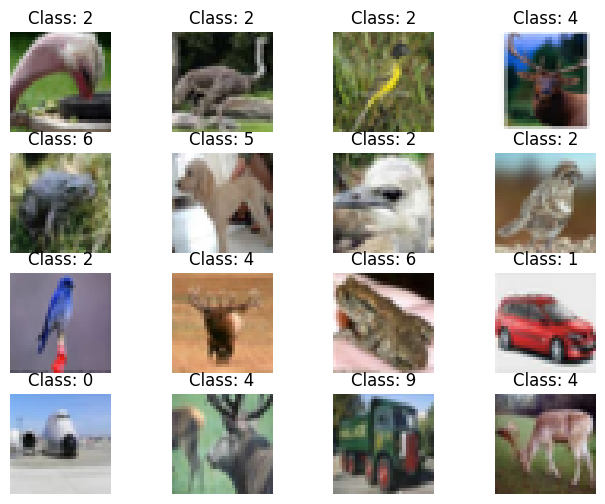

In [6]:
pltsize : int =1
plt.figure(figsize=(8, 6))

i : int
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.axis('off')
    plt.imshow(X_train[i,:,:,:].numpy().reshape(3,32,32).transpose(1,2,0))
    plt.title('Class: '+str(y_train[i].item()))

Se observă că imaginile sunt colorate și aparțin unor clase vizuale distincte, ceea ce justifică utilizarea unei rețele neuronale convoluționale pentru extragerea automată a caracteristicilor. Vizualizarea confirmă faptul că datele sunt citite corect și sunt potrivite pentru antrenarea unui clasificator de imagini.

## Functii utile: antrenare, validare, desenare

În această secțiune sunt definite funcțiile necesare pentru antrenarea și evaluarea rețelei.  
Funcția `train()` parcurge setul de antrenare, realizează propagarea înainte, calculează funcția de cost, aplică backpropagation și actualizează greutățile modelului.  
Funcția `validate()` evaluează modelul pe setul de validare, calculând atât funcția de cost, cât și acuratețea obținută.  
Ambele funcții trimit valorile de loss și acuratețe către TensorBoard pentru monitorizarea vizuală a evoluției modelului pe parcursul antrenării.

In [7]:
def train(model: nn.Module, epoch: int, writer: SummaryWriter, log_interval: int = 200) -> None:
    # Set model to training mode
    """Antrenează modelul pentru o epocă și salvează valorile de loss în TensorBoard."""
    """
    Args:
        model (nn.Module): Modelul neural ce urmează a fi antrenat.
        epoch (int): Numărul epocii curente (folosit la logare).
        writer (SummaryWriter): Writer pentru TensorBoard.
        log_interval (int, optional): Frecvența cu care se afișează loss-ul.
    """
    model.train()

    # Loop over each batch from the training set
    batch_idx : int
    data : torch.Tensor
    target : torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        # Copy data to GPU if needed
        data = data.to(device)
        target = target.to(device)

        # Zero gradient buffers
        optimizer.zero_grad()

        # Pass data through the network
        output : torch.Tensor = model(data)

        # Calculate loss
        loss : torch.Tensor = criterion(output, target)

        # Backpropagate
        loss.backward()

        # Update weights
        optimizer.step()

        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            writer.add_scalar('Loss/train', loss.item(), epoch * len(train_loader) + batch_idx)

In [8]:
def validate(model: nn.Module, summary: SummaryWriter, epoch: int) -> None:
    """Evaluează modelul pe setul de validare și salvează valorile de loss și acuratețe în TensorBoard."""
    """
    Args:
        model (nn.Module): Modelul neural evaluat.
        summary (SummaryWriter): Writer pentru logarea valorilor în TensorBoard.
        epoch (int): Numărul epocii curente (folosit la logare).
    """
    model.eval()
    val_loss : float
    correct : int
    data: torch.Tensor
    target: torch.Tensor
    output: torch.Tensor
    pred: torch.Tensor
    with torch.no_grad():
        val_loss, correct = 0, 0
        for data, target in validation_loader:
            data = data.to(device)
            target = target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item()
            pred = output.argmax(dim=1) # get the index of the max log-probability
            correct += pred.eq(target).sum().item()

        val_loss /= len(validation_loader)
        accuracy : float = 100. * correct / len(validation_loader.dataset)

    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(validation_loader.dataset), accuracy))
    summary.add_scalar("Loss/validation", val_loss, epoch)
    summary.add_scalar("Accuracy/validation", accuracy, epoch)

## Definire model

În această secțiune este implementată rețeaua neuronală convoluțională conform arhitecturii specificate în cerință.  
Modelul conține 8 straturi convoluționale urmate de două straturi fully-connected, având ca funcție de activare ReLU (implicită în PyTorch prin `torch.relu`).  
Straturile de pooling sunt utilizate pentru reducerea dimensiunii spațiale a hărților de caracteristici, iar ultimul strat `Linear` produce 10 ieșiri corespunzătoare celor 10 clase din CIFAR-10.

Modelul conține **6.391.702 parametri antrenabili**, ceea ce îl face semnificativ mai complex decât rețele precum LeNet-5, fiind capabil să extragă reprezentări vizuale mai bogate.

In [9]:
class MyNet(nn.Module):
    """Rețea neuronală convoluțională definită pentru clasificarea imaginilor CIFAR-10."""

    conv1: nn.Conv2d
    conv2: nn.Conv2d
    conv3: nn.Conv2d
    pool4: nn.MaxPool2d

    conv5: nn.Conv2d
    conv6: nn.Conv2d
    pool7: nn.MaxPool2d

    conv8: nn.Conv2d

    fc9: nn.Linear
    fc10: nn.Linear

    def __init__(self) -> None:
        super(MyNet, self).__init__()
        # se declara arhitectura retelei
        # Arhitectura CNN conform cerinței temei
        # prima parte de feature extraction
        self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.conv3=nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.pool4=nn.MaxPool2d(kernel_size=2, stride=2)

        # a doua parte de feature extraction
        self.conv5=nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
        self.conv6=nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3)
        self.pool7=nn.MaxPool2d(kernel_size=3, stride=3)

        # ultima convoluție înainte de fully connected
        self.conv8=nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3)

        # partea de clasificare
        self.fc9=nn.Linear(in_features=1024, out_features=100)
        self.fc10=nn.Linear(in_features=100, out_features=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Realizează propagarea înainte prin arhitectură.
        
        Args:
            x (torch.Tensor): batch de imagini de forma (batch_size, 3, 32, 32)

        Returns:
            torch.Tensor: logits de forma (batch_size, 10)
        """
        # Propagarea înainte prin rețea
        # bloc convoluțional 1
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = self.pool4(x)

        # bloc convoluțional 2
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x=self.pool7(x)

        # ultimă convoluție
        x=torch.relu(self.conv8(x))

        # flatten pentru fully connected
        x = x.view(x.size(0), -1) # Flatten

        # clasificator
        x=torch.relu(self.fc9(x))
        x=self.fc10(x)

        # nu se aplica functie de activare softmax; aceasta e calculata
        # direct in functia de loss, sub forma de log(softmax)
        # fără softmax — este integrat în CrossEntropyLoss
        return x

# instanțiere + sumar
my_net = MyNet()
summary(my_net, (3, 32, 32));

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 30, 30]          896
├─Conv2d: 1-2                            [-1, 64, 28, 28]          18,496
├─Conv2d: 1-3                            [-1, 128, 26, 26]         73,856
├─MaxPool2d: 1-4                         [-1, 128, 13, 13]         --
├─Conv2d: 1-5                            [-1, 256, 11, 11]         295,168
├─Conv2d: 1-6                            [-1, 512, 9, 9]           1,180,160
├─MaxPool2d: 1-7                         [-1, 512, 3, 3]           --
├─Conv2d: 1-8                            [-1, 1024, 1, 1]          4,719,616
├─Linear: 1-9                            [-1, 100]                 102,500
├─Linear: 1-10                           [-1, 10]                  1,010
Total params: 6,391,702
Trainable params: 6,391,702
Non-trainable params: 0
Total mult-adds (M): 201.13
Input size (MB): 0.01
Forward/backward pass size (MB): 1.82
Params size (MB): 24.38
E

## Antrenare si validare

În această secțiune se antrenează modelul `MyNet` pe setul CIFAR-10 pentru 50 de epoci.  
Modelul este mutat pe GPU dacă acesta este disponibil, iar ca algoritm de optimizare a fost utilizat **SGD cu momentum** și **regularizare L2 (weight decay)** pentru a preveni supraînvățarea.  
Funcția de cost folosită este `CrossEntropyLoss`, potrivită pentru clasificare multi-clasă.  
În fiecare epocă se apelează atât `train()`, cât și `validate()` pentru monitorizarea performanței, iar valorile de *loss* și *acuratețe* sunt salvate în TensorBoard pentru vizualizare.

In [10]:
# se trece reteaua pe GPU, daca exista
# Mutarea modelului pe GPU dacă este disponibil
my_net.to(device)

# Optimizatorul folosit (SGD cu momentum și regularizare L2)
optimizer : torch.optim.Optimizer = torch.optim.SGD(my_net.parameters(), lr=0.1, momentum=0.1, weight_decay=1e-3)

# Writer pentru TensorBoard
writer: SummaryWriter = SummaryWriter('runs/CNN_CIFAR10')

# functia de eroare care se optimizeaza de catre optimizator
# Funcția de cost
criterion: nn.Module = nn.CrossEntropyLoss()

In [11]:
%%time
# Numărul de epoci de antrenare
epochs : int = 50

# Bucla principală de antrenare + validare
epoch : int
for epoch in range(1, epochs + 1):
    train(my_net, epoch, writer, 100)
    validate(my_net, writer, epoch)

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.311685
Train Epoch: 1 [6400/50000 (13%)]	Loss: 2.300943
Train Epoch: 1 [12800/50000 (26%)]	Loss: 2.303230
Train Epoch: 1 [19200/50000 (38%)]	Loss: 2.308765
Train Epoch: 1 [25600/50000 (51%)]	Loss: 2.302393
Train Epoch: 1 [32000/50000 (64%)]	Loss: 2.302174
Train Epoch: 1 [38400/50000 (77%)]	Loss: 2.301539
Train Epoch: 1 [44800/50000 (90%)]	Loss: 2.294996

Validation set: Average loss: 2.3016, Accuracy: 1000/10000 (10%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 2.297182
Train Epoch: 2 [6400/50000 (13%)]	Loss: 2.300751
Train Epoch: 2 [12800/50000 (26%)]	Loss: 2.281790
Train Epoch: 2 [19200/50000 (38%)]	Loss: 2.317791
Train Epoch: 2 [25600/50000 (51%)]	Loss: 2.160213
Train Epoch: 2 [32000/50000 (64%)]	Loss: 2.167271
Train Epoch: 2 [38400/50000 (77%)]	Loss: 2.129019
Train Epoch: 2 [44800/50000 (90%)]	Loss: 2.265530

Validation set: Average loss: 2.1256, Accuracy: 2268/10000 (23%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 2.025680
Train Epoch: 3 [6400/50000 (13%)]

Rețeaua neuronală convoluțională implementată pe CIFAR-10 a atins o acuratețe maximă de ~73% pe setul de validare. Pe parcursul antrenării, loss-ul de antrenare continuă să scadă, însă loss-ul de validare începe să crească după aproximativ 30 de epoci, ceea ce indică apariția fenomenului de overfitting. Evoluția funcției de cost și a acurateții observată în TensorBoard confirmă această tendință. O oprire timpurie (early stopping) sau tehnici suplimentare de regularizare ar putea stabiliza performanța.

## Reprezentarea grafică a funcției de cost și acurateții cu TensorBoard

În această secțiune sunt afișate graficele reprezentând evoluția funcției de cost (loss) și a acurateții pe parcursul antrenării modelului.  
Valorile au fost salvate în directorul `runs/`, iar TensorBoard permite vizualizarea lor în timp real și compararea eventualelor rulari diferite ale modelului.

In [12]:
# Listăm fișierele existente, pentru a confirma că au fost generate logurile TensorBoard
%ls
%ls runs

 Volume in drive D is alte fisiere
 Volume Serial Number is 2A0A-D44A

 Directory of D:\Python\Laborator

28.12.2025  21:33    <DIR>          .
28.12.2025  21:33    <DIR>          ..
26.12.2025  23:02    <DIR>          .ipynb_checkpoints
26.12.2025  23:04           110.832 01_PyTorch_CNN.ipynb
26.12.2025  22:37    <DIR>          data
28.12.2025  21:33           127.756 IA_tema5_Visan_AntonioValentin_10LF244.ipynb
26.12.2025  22:48    <DIR>          runs
26.12.2025  22:06    <DIR>          venv_pytorch
               2 File(s)        238.588 bytes
               6 Dir(s)  871.011.569.664 bytes free
 Volume in drive D is alte fisiere
 Volume Serial Number is 2A0A-D44A

 Directory of D:\Python\Laborator\runs

26.12.2025  22:48    <DIR>          .
26.12.2025  22:48    <DIR>          ..
28.12.2025  21:33    <DIR>          CNN_CIFAR10
               0 File(s)              0 bytes
               3 Dir(s)  871.011.569.664 bytes free


In [13]:
# Activăm extensia TensorBoard în notebook
%load_ext tensorboard
# Lansăm TensorBoard pentru vizualizarea graficelor
%tensorboard --logdir=runs

Se observă scăderea funcției de cost pe parcursul antrenării și îmbunătățirea acurateții pe setul de validare, ceea ce indică faptul că modelul învață progresiv caracteristicile relevante ale imaginilor CIFAR-10. Modelul CNN implementat atinge ~70% acuratețe pe CIFAR-10. Evoluția funcțiilor de cost și acuratețe arată o învățare corectă inițial, urmată de stagnare și fluctuații, specifice overfitting-ului. Graficele TensorBoard confirmă antrenarea reușită și permit monitorizarea vizuală a performanței modelului.